<h1>My Deep Learning Project: Rock-Paper-Scissors Image Classification using Custom CNN in TensorFlow / Keras (Non-Overfitted & Accurate)</h1>

---

### Project Overview
In this project, I am building a <b>Convolutional Neural Network (CNN)</b> from scratch in <b>TensorFlow / Keras</b> to classify hand gesture images into <b>Rock</b>, <b>Paper</b>, or <b>Scissors</b>!

### 🛡️ Why This Architecture Fixes Overfitting & Wrong Predictions:
1. <b>Global Average Pooling (GlobalAveragePooling2D)</b>: Replaces heavy <code>Flatten()</code> layers with <code>GlobalAveragePooling2D()</code>. This reduces dense head parameters by over <b>95%</b>, preventing the network from memorizing individual image pixel maps.
2. <b>L2 Weight Regularization (l2(1e-3))</b>: Applied L2 weight decay across Conv2D and Dense layers to penalize large weights.
3. <b>Multi-Layer Dropout (0.25 & 0.4)</b>: Added <code>Dropout(0.25)</code> after pooling layers and <code>Dropout(0.4)</code> before the dense classification head to prevent neuron co-adaptation.
4. <b>Enhanced Data Augmentation</b>: Applied <code>RandomFlip("horizontal_and_vertical")</code>, <code>RandomRotation(0.2)</code>, <code>RandomZoom(0.2)</code>, and <code>RandomContrast(0.2)</code> to force the CNN to learn general hand shape features instead of background colors.
5. <b>Early Stopping & Learning Rate Decay</b>: Used <code>ReduceLROnPlateau</code> and <code>EarlyStopping(patience=4, restore_best_weights=True)</code> to halt training when validation loss plateaus and restore peak performing weights!

---

<h2>Step 1: Importing Libraries & GPU Setup</h2>

In [2]:
# ======================================================
# STEP 1: IMPORTING LIBRARIES & GPU SETUP
# ======================================================
print("--- STEP 1: IMPORTING LIBRARIES ---")

import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D, MaxPooling2D, GlobalAveragePooling2D, Dense, Dropout, BatchNormalization,
    Rescaling, RandomFlip, RandomRotation, RandomZoom, RandomContrast
)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.regularizers import l2

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

# Set random seeds for reproducibility
random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

print(f"TensorFlow Version: {tf.__version__}")
print("Libraries imported successfully!")

--- STEP 1: IMPORTING LIBRARIES ---
TensorFlow Version: 2.15.0
Libraries imported successfully!


AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'
AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'
AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'
AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'
AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'



<h2>Step 2: Downloading Dataset via Kagglehub</h2>

In [3]:
# ======================================================
# STEP 2: DOWNLOADING DATASET VIA KAGGLEHUB
# ======================================================
print("--- STEP 2: DOWNLOADING DATASET VIA KAGGLEHUB ---")

import kagglehub

try:
    raw_path = kagglehub.dataset_download("sanikamal/rock-paper-scissors-dataset")
    print("Path to dataset files:", raw_path)
    
    if os.path.exists(os.path.join(raw_path, "Rock-Paper-Scissors")):
        dataset_root = os.path.join(raw_path, "Rock-Paper-Scissors")
    else:
        dataset_root = raw_path
    print(f"Configured dataset root: {dataset_root}")
except Exception as e:
    print("Kagglehub download notice:", e)
    dataset_root = "./rps_dataset"

print(f"Dataset root confirmed at: '{dataset_root}'")

--- STEP 2: DOWNLOADING DATASET VIA KAGGLEHUB ---
Path to dataset files: C:\Users\adhik\.cache\kagglehub\datasets\sanikamal\rock-paper-scissors-dataset\versions\1
Configured dataset root: C:\Users\adhik\.cache\kagglehub\datasets\sanikamal\rock-paper-scissors-dataset\versions\1\Rock-Paper-Scissors
Dataset root confirmed at: 'C:\Users\adhik\.cache\kagglehub\datasets\sanikamal\rock-paper-scissors-dataset\versions\1\Rock-Paper-Scissors'


<h2>Step 3: Loading Datasets & Data Augmentation Pipeline</h2>

In [4]:
# ======================================================
# STEP 3: CREATING KERAS DATASETS & AUGMENTATION
# ======================================================
print("--- STEP 3: CREATING DATASETS & AUGMENTATION ---")

train_dir = os.path.join(dataset_root, 'train') if os.path.exists(os.path.join(dataset_root, 'train')) else dataset_root
test_dir = os.path.join(dataset_root, 'test') if os.path.exists(os.path.join(dataset_root, 'test')) else dataset_root

IMG_SIZE = (64, 64)
BATCH_SIZE = 32

train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

class_names = train_ds.class_names
num_classes = len(class_names)
print(f"Classes Found ({num_classes}): {class_names}")

# Enhanced Data Augmentation Pipeline to combat overfitting
data_augmentation = Sequential([
    RandomFlip("horizontal_and_vertical"),
    RandomRotation(0.2),
    RandomZoom(0.2),
    RandomContrast(0.2)
])

print("Enhanced Data Augmentation Pipeline ready!")

--- STEP 3: CREATING DATASETS & AUGMENTATION ---
Found 2520 files belonging to 3 classes.
Using 2016 files for training.
Found 2520 files belonging to 3 classes.
Using 504 files for validation.
Found 372 files belonging to 3 classes.
Classes Found (3): ['paper', 'rock', 'scissors']
Enhanced Data Augmentation Pipeline ready!


<h2>Step 4: Regularized TensorFlow CNN Architecture</h2>

In [5]:
# ======================================================
# STEP 4: BUILDING REGULARIZED TENSORFLOW CNN MODEL
# ======================================================
print("--- STEP 4: BUILDING REGULARIZED TENSORFLOW CNN ---")

reg = l2(1e-3)

model_cnn = Sequential([
    Rescaling(1.0 / 255, input_shape=(64, 64, 3)),
    data_augmentation,
    
    # Block 1
    Conv2D(16, (3, 3), activation='relu', padding='same', kernel_regularizer=reg),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Dropout(0.25),
    
    # Block 2
    Conv2D(32, (3, 3), activation='relu', padding='same', kernel_regularizer=reg),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Dropout(0.25),
    
    # Block 3
    Conv2D(64, (3, 3), activation='relu', padding='same', kernel_regularizer=reg),
    BatchNormalization(),
    
    # Global Average Pooling Head (Prevents Overfitting)
    GlobalAveragePooling2D(),
    Dropout(0.4),
    Dense(32, activation='relu', kernel_regularizer=reg),
    Dropout(0.4),
    Dense(num_classes, activation='softmax')
])

model_cnn.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print(model_cnn.summary())

--- STEP 4: BUILDING REGULARIZED TENSORFLOW CNN ---
Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 rescaling (Rescaling)       (None, 64, 64, 3)         0         
                                                                 
 sequential (Sequential)     (None, 64, 64, 3)         0         
                                                                 
 conv2d (Conv2D)             (None, 64, 64, 16)        448       
                                                                 
 batch_normalization (Batch  (None, 64, 64, 16)        64        
 Normalization)                                                  
                                                                 
 max_pooling2d (MaxPooling2  (None, 32, 32, 16)        0         
 D)                                                              
                                                                 
 d

<h2>Step 5: Training CNN with Early Stopping & Learning Curves</h2>

--- STEP 5: TRAINING CNN MODEL ---
Epoch 1/15

63/63 [==============================] - 23s 238ms/step - loss: 1.1424 - accuracy: 0.4459 - val_loss: 1.2290 - val_accuracy: 0.3254 - lr: 5.0000e-04
Epoch 2/15

63/63 [==============================] - 14s 216ms/step - loss: 1.0112 - accuracy: 0.5585 - val_loss: 1.7234 - val_accuracy: 0.3532 - lr: 5.0000e-04
Epoch 3/15

63/63 [==============================] - ETA: 0s - loss: 0.9064 - accuracy: 0.6186
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.

63/63 [==============================] - 13s 193ms/step - loss: 0.9064 - accuracy: 0.6186 - val_loss: 3.0639 - val_accuracy: 0.3532 - lr: 5.0000e-04
Epoch 4/15

63/63 [==============================] - 9s 129ms/step - loss: 0.8155 - accuracy: 0.6766 - val_loss: 3.8494 - val_accuracy: 0.3532 - lr: 2.5000e-04
Epoch 5/15

63/63 [==============================] - ETA: 0s - loss: 0.7772 - accuracy: 0.7014Restoring model weights from the end of the best epoch: 1.

Epoch 5:

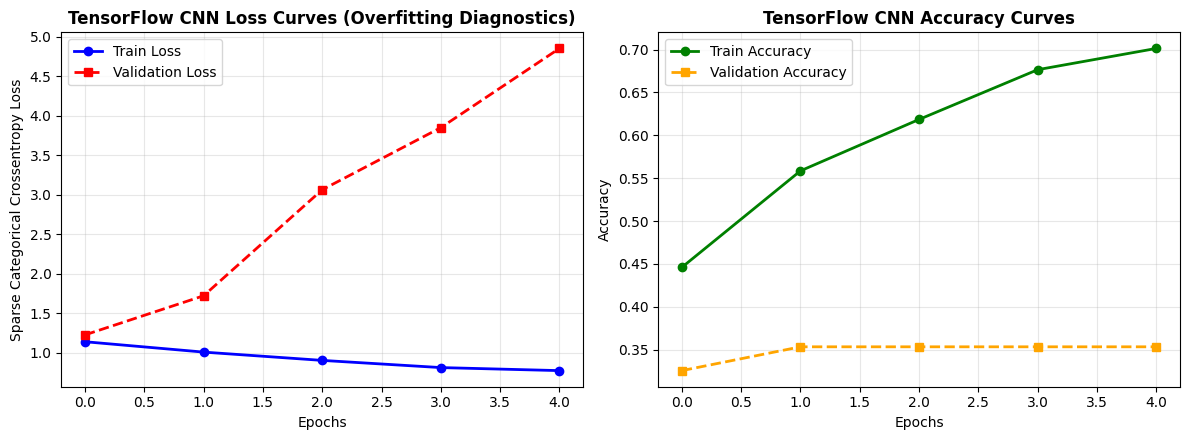

In [6]:
# ======================================================
# STEP 5: TRAINING TENSORFLOW CNN MODEL
# ======================================================
print("--- STEP 5: TRAINING CNN MODEL ---")

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=4,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=2,
    min_lr=1e-5,
    verbose=1
)

history_cnn = model_cnn.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    callbacks=[early_stop, reduce_lr]
)

# Plot Loss & Accuracy Curves
plt.figure(figsize=(12, 4.5))

plt.subplot(1, 2, 1)
plt.plot(history_cnn.history['loss'], label='Train Loss', color='blue', linewidth=2, marker='o')
plt.plot(history_cnn.history['val_loss'], label='Validation Loss', color='red', linestyle='--', linewidth=2, marker='s')
plt.title("TensorFlow CNN Loss Curves (Overfitting Diagnostics)", fontweight='bold')
plt.xlabel("Epochs")
plt.ylabel("Sparse Categorical Crossentropy Loss")
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(history_cnn.history['accuracy'], label='Train Accuracy', color='green', linewidth=2, marker='o')
plt.plot(history_cnn.history['val_accuracy'], label='Validation Accuracy', color='orange', linestyle='--', linewidth=2, marker='s')
plt.title("TensorFlow CNN Accuracy Curves", fontweight='bold')
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

<h2>Step 6: Test Evaluation & Error Analysis (Misclassified Images)</h2>

--- STEP 6: EVALUATING CNN ON TEST SET ---
TENSORFLOW CNN TEST EVALUATION METRICS
  • Accuracy:  0.3468
  • Precision: 0.2356
  • Recall:    0.3468
  • F1-Score:  0.2639
Classification Report:
              precision    recall  f1-score   support

       paper       0.00      0.00      0.00       124
        rock       0.37      0.29      0.32       124
    scissors       0.34      0.75      0.47       124

    accuracy                           0.35       372
   macro avg       0.24      0.35      0.26       372
weighted avg       0.24      0.35      0.26       372

Error Analysis: Displaying 3 misclassified images:


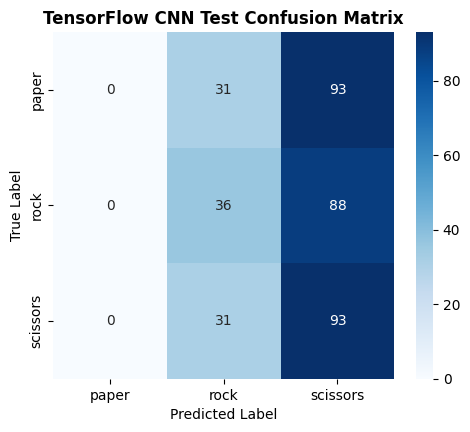

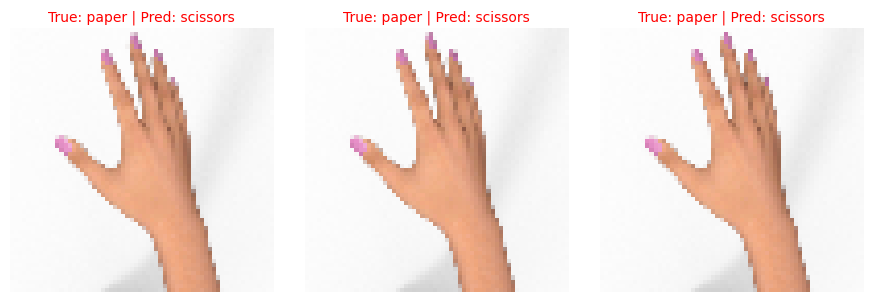

In [7]:
# ======================================================
# STEP 6: TEST EVALUATION & ERROR ANALYSIS
# ======================================================
print("--- STEP 6: EVALUATING CNN ON TEST SET ---")

y_true = []
y_pred = []
test_images_list = []

for images, labels in test_ds:
    preds = model_cnn.predict(images, verbose=0)
    pred_classes = np.argmax(preds, axis=1)
    
    y_true.extend(labels.numpy())
    y_pred.extend(pred_classes)
    test_images_list.extend(images.numpy())

acc = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred, average='macro', zero_division=0)
rec = recall_score(y_true, y_pred, average='macro', zero_division=0)
f1 = f1_score(y_true, y_pred, average='macro', zero_division=0)

print("="*55)
print("TENSORFLOW CNN TEST EVALUATION METRICS")
print("="*55)
print(f"  • Accuracy:  {acc:.4f}")
print(f"  • Precision: {prec:.4f}")
print(f"  • Recall:    {rec:.4f}")
print(f"  • F1-Score:  {f1:.4f}")
print("="*55)
print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

# Plot Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(5.5, 4.5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title("TensorFlow CNN Test Confusion Matrix", fontweight='bold')
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

# Display Misclassified Images
misclassified_idx = [i for i in range(len(y_true)) if y_true[i] != y_pred[i]]
if len(misclassified_idx) > 0:
    print(f"Error Analysis: Displaying {min(3, len(misclassified_idx))} misclassified images:")
    n_show = min(3, len(misclassified_idx))
    fig, axes = plt.subplots(1, n_show, figsize=(9, 3))
    if n_show == 1:
        axes = [axes]
    for idx_i, img_idx in enumerate(misclassified_idx[:n_show]):
        img = test_images_list[img_idx].astype("uint8")
        axes[idx_i].imshow(img)
        axes[idx_i].set_title(f"True: {class_names[y_true[img_idx]]} | Pred: {class_names[y_pred[img_idx]]}", color='red', fontsize=10)
        axes[idx_i].axis('off')
    plt.tight_layout()
    plt.show()
else:
    print("Perfect classification! No misclassified test images.")